In [1]:
import numpy as np
import pandas as pd

In [2]:
courses = pd.read_csv('courses.csv')
nov = pd.read_csv('reg-month1.csv')
dec = pd.read_csv('reg-month2.csv')
student = pd.read_csv('students.csv')


In [3]:
# pd.concat
# ignore_index
# df.append
# mullitindex -> fetch using iloc
# concat dataframes horizontally

In [4]:
reg = pd.concat([nov,dec],ignore_index=True)

In [6]:
# inner join 
student.merge(reg ,how='inner',on='student_id').head()

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5


In [12]:
#left join
courses


,course_id,course_name,price
0,1,python,2499
1,2,sql,3499
2,3,data analysis,4999
3,4,machine learning,9999
4,5,tableau,2499
5,6,power bi,1899
6,7,ms sxcel,1599
7,8,pandas,1099
8,9,plotly,699
9,10,pyspark,2499


In [10]:
reg

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [13]:
courses.merge(reg,how='left',on='course_id')

,course_id,course_name,price,student_id
0,1,python,2499,23.0
1,1,python,2499,18.0
2,1,python,2499,1.0
3,1,python,2499,15.0
4,1,python,2499,21.0
5,1,python,2499,25.0
6,1,python,2499,12.0
7,1,python,2499,14.0
8,1,python,2499,38.0
9,2,sql,3499,19.0


In [14]:
student

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
6,7,Tarun Thaker,9
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8


In [25]:
temp_df = pd.DataFrame(
    { 'student_id':[26,27,28],
     'name':['vijay','sagar','hrishabh'],
      'partner':[23,1,3]
    }
)
student = pd.concat([student,temp_df],ignore_index='True')

In [26]:
reg.merge(student,how='right',on='student_id')

,student_id,course_id,name,partner
0,1,1.0,Kailash Harjo,23
1,1,6.0,Kailash Harjo,23
2,1,10.0,Kailash Harjo,23
3,1,9.0,Kailash Harjo,23
4,2,5.0,Esha Butala,1
...,...,...,...,...
58,26,NaN,sagar,1
59,28,NaN,hrishabh,3
60,26,NaN,vijay,23
61,27,NaN,sagar,1


In [38]:
# 1. find total revenue generated
reg.head()

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9


In [39]:
courses.head()

,course_id,course_name,price
0,1,python,2499
1,2,sql,3499
2,3,data analysis,4999
3,4,machine learning,9999
4,5,tableau,2499


In [36]:
reg.merge(courses,how='inner',on='course_id')['price'].sum()

np.int64(154247)

In [70]:
# 2. find month by month revenue 
regs = pd.concat([nov,dec],keys=['nov','dec']).reset_index()
regs.merge(courses,how='inner',on='course_id').groupby('level_0')['price'].sum()

level_0
dec    65072
nov    89175
Name: price, dtype: int64

In [74]:
# 3. Print the registration table
# cols -> name -> course -> price
reg.merge(courses,how='inner',on='course_id').merge(student,how='inner',on='student_id')[['name','course_name','price']]


,name,course_name,price
0,Chhavi Lachman,python,2499
1,Preet Sha,tableau,2499
2,Fardeen Mahabir,power bi,1899
3,Chhavi Lachman,machine learning,9999
4,Elias Dodiya,plotly,699
5,Fardeen Mahabir,python,2499
6,Kailash Harjo,python,2499
7,Tarun Thaker,pandas,1099
8,Yash Sethi,data analysis,4999
9,Preet Sha,python,2499


In [83]:
# 4. Plot bar chart for revenue/course
revenue = reg.merge(courses,how='inner',on='course_id').groupby('course_name')['price'].sum()
revenue

course_name
data analysis       24995
machine learning    39996
ms sxcel             7995
pandas               4396
plotly               3495
power bi            11394
pyspark             14994
python              22491
sql                  6998
tableau             17493
Name: price, dtype: int64

<Axes: xlabel='course_name'>

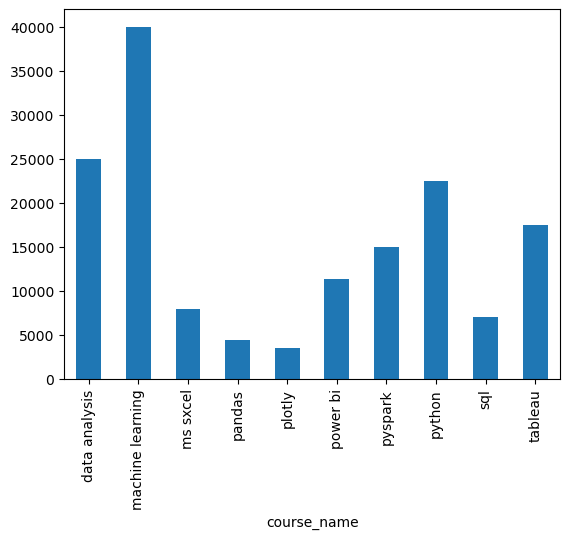

In [84]:
revenue.plot(kind='bar')

In [95]:
# 5. find students who enrolled in both the months 
coman_student = np.intersect1d(nov['student_id'],dec['student_id'])
student[student['student_id'].isin(coman_student)]

,student_id,name,partner
0,1,Kailash Harjo,23
2,3,Parveen Bhalla,3
6,7,Tarun Thaker,9
10,11,David Mukhopadhyay,20
15,16,Elias Dodiya,25
16,17,Yasmin Palan,7
17,18,Fardeen Mahabir,13
21,22,Yash Sethi,21
22,23,Chhavi Lachman,18


In [ ]:
# 6. find course that got no enrollment
# courses['course_id']
# regs['course_id']